# 10 – ASRS Market Context Study

**Base** : F1+F2 filtered ASRS (PF 1.17, Sharpe 0.83, +8,008 pts)  
**Goal** : Add market context derived from the existing 5-min data to further improve edge

## Context signals tested
| # | Signal | Description |
|---|--------|-------------|
| C1 | ATR regime | 14-day rolling ATR — trade only in normal volatility band |
| C2 | Pre-session direction | Move from 08:00 open → 09:15 signal bar |
| C3 | Opening gap | Yesterday close → today 08:00 open |
| C4 | Monthly seasonality | Which months are structurally weak/strong |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

print(f'ROOT = {ROOT}')

ROOT = c:\Users\ali\Desktop\Projet-INFO-2AS2


## 1. Load Data

In [2]:
DATA_PATH = ROOT / 'data' / 'dax-5m_bk.csv'

raw = pd.read_csv(
    DATA_PATH, sep=';', header=None,
    names=['date', 'time', 'open', 'high', 'low', 'close', 'volume'],
)
raw['datetime'] = pd.to_datetime(raw['date'] + ' ' + raw['time'], format='%d/%m/%Y %H:%M')
raw = raw.drop(columns=['date', 'time']).set_index('datetime').sort_index()

START_DATE = '2006-01-01'
raw = raw[raw.index >= START_DATE]

print(f'Loaded {len(raw):,} rows  {raw.index[0].date()} → {raw.index[-1].date()}')

Loaded 998,622 rows  2006-01-02 → 2026-04-06


## 2. Parameters

In [3]:
# ── Base strategy (F1+F2) ──────────────────────────────────────────────────────
ENTRY_BUFFER  = 2
EOD_EXIT_TIME = '17:30'
SIGNAL_TIME   = '09:15'
RANGE_MIN     = 10
RANGE_MAX     = 55

# ── Context parameters (to be explored) ───────────────────────────────────────
ATR_PERIOD    = 14    # C1: rolling days for ATR
ATR_LOW       = 50    # C1: below this → skip (too quiet)
ATR_HIGH      = 250   # C1: above this → skip (crisis)
PRESESSION_START = '08:00'   # C2: pre-session open reference

print('Parameters set.')

Parameters set.


## 3. Build Daily Context Table
One row per trading day with all context signals pre-computed.

In [4]:
# ── Daily OHLC (session: 08:00 – 17:30) ──────────────────────────────────────
session = raw.between_time('08:00', '17:30')
daily = session.groupby(session.index.date).agg(
    open  = ('open',  'first'),
    high  = ('high',  'max'),
    low   = ('low',   'min'),
    close = ('close', 'last'),
)
daily.index = pd.to_datetime(daily.index)
daily = daily[daily.index >= START_DATE]

# ── C1: Daily ATR (true range on daily bars) ──────────────────────────────────
daily['prev_close'] = daily['close'].shift(1)
daily['tr'] = np.maximum(
    daily['high'] - daily['low'],
    np.maximum(
        abs(daily['high'] - daily['prev_close']),
        abs(daily['low']  - daily['prev_close'])
    )
)
daily['atr14'] = daily['tr'].rolling(ATR_PERIOD).mean()

# ATR regime buckets
daily['atr_regime'] = pd.cut(
    daily['atr14'],
    bins=[0, ATR_LOW, 100, 150, ATR_HIGH, 9999],
    labels=['very_low', 'low', 'normal', 'elevated', 'crisis']
)

# ── C3: Opening gap (prev close → 08:00 open) ─────────────────────────────────
daily['gap_pts'] = daily['open'] - daily['prev_close']
daily['gap_abs'] = daily['gap_pts'].abs()
daily['gap_pct'] = (daily['gap_pts'] / daily['prev_close'] * 100).round(3)

print(f'Daily rows : {len(daily):,}')
print(f'\nATR14 stats:')
print(daily['atr14'].describe().round(1))
print(f'\nATR regime distribution:')
print(daily['atr_regime'].value_counts().sort_index())
print(f'\nGap stats (pts):')
print(daily['gap_pts'].describe().round(1))

Daily rows : 5,140

ATR14 stats:
count    5126.0
mean      154.7
std        84.3
min        43.4
25%       101.6
50%       133.4
75%       187.8
max       783.7
Name: atr14, dtype: float64

ATR regime distribution:
atr_regime
very_low      25
low         1199
normal      1796
elevated    1591
crisis       515
Name: count, dtype: int64

Gap stats (pts):
count    5139.0
mean       -0.6
std       115.3
min     -1332.2
25%       -49.0
50%         2.1
75%        53.4
max       887.3
Name: gap_pts, dtype: float64


In [5]:
# ── C2: Pre-session direction (08:00 open → 09:15 signal bar open) ────────────
bars_0800  = raw[raw.index.strftime('%H:%M') == PRESESSION_START].copy()
bars_0800['trade_date'] = bars_0800.index.date
bars_0800_by_date = bars_0800.set_index('trade_date')['open']

bars_sig   = raw[raw.index.strftime('%H:%M') == SIGNAL_TIME].copy()
bars_sig['trade_date'] = bars_sig.index.date
bars_sig['bar_range']  = bars_sig['high'] - bars_sig['low']
bars_sig = bars_sig[(bars_sig['bar_range'] > 0.1) & (bars_sig['bar_range'] < 500)]
bars_sig_by_date = bars_sig.set_index('trade_date')

# Build per-day context row
context_rows = []
for trade_date in bars_sig_by_date.index.unique():
    ts_date = pd.Timestamp(trade_date)

    row_sig = bars_sig_by_date.loc[trade_date]
    if isinstance(row_sig, pd.DataFrame):
        row_sig = row_sig.iloc[0]

    sig_high  = row_sig['high']
    sig_low   = row_sig['low']
    sig_range = sig_high - sig_low

    # F1+F2 filters
    if ts_date.dayofweek == 4:           continue   # F1: no Friday
    if not (RANGE_MIN <= sig_range <= RANGE_MAX): continue  # F2: range filter

    # Pre-session move
    if trade_date in bars_0800_by_date.index:
        open_0800 = bars_0800_by_date.loc[trade_date]
        if isinstance(open_0800, pd.Series):
            open_0800 = open_0800.iloc[0]
        presession_move = row_sig['open'] - open_0800   # + = up, - = down
    else:
        presession_move = np.nan

    # Daily context from daily table
    if ts_date in daily.index:
        d = daily.loc[ts_date]
        atr14      = d['atr14']
        atr_regime = d['atr_regime']
        gap_pts    = d['gap_pts']
        gap_abs    = d['gap_abs']
    else:
        atr14 = atr_regime = gap_pts = gap_abs = np.nan

    context_rows.append({
        'trade_date'      : ts_date,
        'sig_high'        : sig_high,
        'sig_low'         : sig_low,
        'sig_range'       : round(sig_range, 2),
        'presession_move' : round(presession_move, 2) if not np.isnan(presession_move) else np.nan,
        'atr14'           : round(atr14, 1) if not np.isnan(atr14) else np.nan,
        'atr_regime'      : atr_regime,
        'gap_pts'         : round(gap_pts, 2) if not np.isnan(gap_pts) else np.nan,
        'gap_abs'         : round(gap_abs, 2) if not np.isnan(gap_abs) else np.nan,
        'month'           : ts_date.month,
        'dow'             : ts_date.dayofweek,
    })

ctx = pd.DataFrame(context_rows).set_index('trade_date').sort_index()
ctx = ctx.dropna(subset=['atr14'])  # need ATR to be valid

print(f'Context table : {len(ctx):,} days (F1+F2 filtered, ATR valid)')
print(f'\nPre-session move stats (pts):')
print(ctx['presession_move'].describe().round(1))

Context table : 2,901 days (F1+F2 filtered, ATR valid)

Pre-session move stats (pts):
count    2901.0
mean       -1.7
std        47.2
min      -241.5
25%       -28.1
50%        -1.1
75%        25.4
max       218.0
Name: presession_move, dtype: float64


## 4. Backtest Engine

In [6]:
def simulate_day(day_bars, sig_high, sig_low):
    """Core ASRS sim — no filters, just execution."""
    if day_bars.empty:
        return None

    entry_long  = sig_high + ENTRY_BUFFER
    entry_short = sig_low  - ENTRY_BUFFER
    stop_long   = entry_short
    stop_short  = entry_long

    direction = entry_price = entry_time = stop = None

    for ts, bar in day_bars.iterrows():
        if direction is not None:
            break
        bh, bl = bar['high'], bar['low']
        long_hit  = bh >= entry_long
        short_hit = bl <= entry_short
        if long_hit and short_hit:
            if bar['open'] >= entry_long:
                direction, entry_price, stop = 'long',  entry_long,  stop_long
            else:
                direction, entry_price, stop = 'short', entry_short, stop_short
            entry_time = ts
        elif long_hit:
            direction, entry_price, stop, entry_time = 'long',  entry_long,  stop_long,  ts
        elif short_hit:
            direction, entry_price, stop, entry_time = 'short', entry_short, stop_short, ts

    if direction is None:
        return None

    exit_price = exit_time = None
    exit_reason = 'eod'
    max_adverse = max_favorable = 0.0

    for ts, bar in day_bars[day_bars.index >= entry_time].iterrows():
        bh, bl = bar['high'], bar['low']
        if direction == 'long':
            max_adverse   = max(max_adverse,   entry_price - bl)
            max_favorable = max(max_favorable, bh - entry_price)
            if bl <= stop:
                exit_price, exit_time, exit_reason = stop, ts, 'stop'
                break
        else:
            max_adverse   = max(max_adverse,   bh - entry_price)
            max_favorable = max(max_favorable, entry_price - bl)
            if bh >= stop:
                exit_price, exit_time, exit_reason = stop, ts, 'stop'
                break

    if exit_price is None:
        last = day_bars[day_bars.index >= entry_time].iloc[-1]
        exit_price, exit_time, exit_reason = last['close'], last.name, 'eod'

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)

    return {
        'direction'    : direction,
        'entry_price'  : round(entry_price,  2),
        'exit_price'   : round(exit_price,   2),
        'exit_reason'  : exit_reason,
        'pnl'          : round(pnl,          2),
        'max_adverse'  : round(max_adverse,  2),
        'max_favorable': round(max_favorable,2),
    }


def run_on_context(ctx_df):
    """Run backtest on a pre-filtered context DataFrame."""
    trades = []
    for trade_date, crow in ctx_df.iterrows():
        day_start = pd.Timestamp(f"{trade_date.date()} 09:20")
        day_end   = pd.Timestamp(f"{trade_date.date()} {EOD_EXIT_TIME}")
        day_bars  = raw.loc[day_start:day_end]
        if len(day_bars) < 2:
            continue
        result = simulate_day(day_bars, crow['sig_high'], crow['sig_low'])
        if result is not None:
            result['trade_date'] = trade_date
            trades.append(result)
    df = pd.DataFrame(trades).set_index('trade_date').sort_index()
    return df


print('Backtest engine defined. Running F1+F2 base on context table...')
df_base = run_on_context(ctx)
print(f'F1+F2 base trades : {len(df_base):,}  |  Total PnL : {df_base["pnl"].sum():,.0f} pts')

Backtest engine defined. Running F1+F2 base on context table...
F1+F2 base trades : 2,901  |  Total PnL : 8,051 pts


In [7]:
def metrics(df, label=''):
    if df.empty:
        return {'label': label, 'n_trades': 0}
    w = df[df['pnl'] > 0]
    l = df[df['pnl'] < 0]
    pf = (w['pnl'].sum() / abs(l['pnl'].sum())) if len(l) else np.inf
    sh = (df['pnl'].mean() / df['pnl'].std() * np.sqrt(252)) if df['pnl'].std() > 0 else 0
    cum = df['pnl'].cumsum()
    dd  = (cum - cum.cummax()).min()
    return {
        'label'         : label,
        'n_trades'      : len(df),
        'win_rate_%'    : round((df['pnl'] > 0).mean()*100, 1),
        'avg_win'       : round(w['pnl'].mean(), 1) if len(w) else 0,
        'avg_loss'      : round(l['pnl'].mean(), 1) if len(l) else 0,
        'profit_factor' : round(pf, 2),
        'total_pnl'     : round(df['pnl'].sum(), 0),
        'avg_trade'     : round(df['pnl'].mean(), 2),
        'sharpe'        : round(sh, 2),
        'max_dd'        : round(dd, 0),
    }

print(pd.DataFrame([metrics(df_base, 'F1+F2 base')]).set_index('label').to_string())

            n_trades  win_rate_%  avg_win  avg_loss  profit_factor  total_pnl  avg_trade  sharpe  max_dd
label                                                                                                   
F1+F2 base      2901        29.6     63.2     -22.6           1.17     8051.0       2.78    0.83 -1863.0


## 5. C1 — ATR Regime Analysis

In [8]:
# Attach PnL to context table
ctx_trades = ctx.join(df_base[['pnl', 'direction', 'exit_reason', 'max_adverse', 'max_favorable']],
                      how='inner')

# Performance by ATR regime
atr_perf = ctx_trades.groupby('atr_regime', observed=True).agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl   = ('pnl', 'mean'),
    avg_win   = ('pnl', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    avg_loss  = ('pnl', lambda x: x[x < 0].mean() if (x < 0).any() else 0),
).round(1)

print('=== Performance by ATR14 Regime ===')
print(atr_perf.to_string())

# ATR numeric buckets for finer resolution
ctx_trades['atr_bucket'] = pd.cut(
    ctx_trades['atr14'],
    bins=[0, 50, 75, 100, 125, 150, 175, 200, 250, 9999],
    labels=['<50', '50-75', '75-100', '100-125', '125-150', '150-175', '175-200', '200-250', '>250']
)
atr_fine = ctx_trades.groupby('atr_bucket', observed=True).agg(
    trades  = ('pnl', 'count'),
    avg_pnl = ('pnl', 'mean'),
    win_rate= ('pnl', lambda x: (x > 0).mean() * 100),
).round(1)

print('\n=== Fine ATR Buckets ===')
print(atr_fine.to_string())

=== Performance by ATR14 Regime ===
            trades  total_pnl  win_rate  avg_pnl  avg_win  avg_loss
atr_regime                                                         
crisis         378     6409.4      29.1     17.0    132.8     -30.6
elevated      1133     1991.1      26.9      1.8     72.3     -24.2
low            403      434.6      36.0      1.1     33.5     -17.2
normal         983     -795.5      30.0     -0.8     42.8     -19.5
very_low         4       11.2      75.0      2.8      8.8     -15.1

=== Fine ATR Buckets ===
            trades  avg_pnl  win_rate
atr_bucket                           
<50              4      2.8      75.0
50-75           98      2.2      39.8
75-100         305      0.7      34.8
100-125        522     -1.1      31.4
125-150        461     -0.4      28.4
150-175        372      3.3      31.2
175-200        353     -1.4      24.1
200-250        408      3.1      25.5
>250           378     17.0      29.1


In [9]:
# Find optimal ATR band
results_atr = {}
for lo, hi in [(50, 150), (50, 175), (50, 200), (75, 150), (75, 175), (75, 200), (60, 160), (60, 200)]:
    mask = (ctx['atr14'] >= lo) & (ctx['atr14'] <= hi)
    df_v = run_on_context(ctx[mask])
    results_atr[f'ATR {lo}–{hi}'] = metrics(df_v, f'ATR {lo}–{hi}')

atr_scan = pd.DataFrame(results_atr.values()).set_index('label')
print('=== ATR Band Scan (on top of F1+F2) ===')
print(atr_scan[['n_trades','win_rate_%','profit_factor','total_pnl','avg_trade','sharpe','max_dd']].to_string())

=== ATR Band Scan (on top of F1+F2) ===
            n_trades  win_rate_%  profit_factor  total_pnl  avg_trade  sharpe  max_dd
label                                                                                
ATR 50–150      1388        31.8           0.98     -367.0      -0.26   -0.13 -1225.0
ATR 50–175      1760        31.6           1.04      871.0       0.49    0.21  -932.0
ATR 50–200      2113        30.4           1.01      378.0       0.18    0.07 -2094.0
ATR 75–150      1288        31.1           0.97     -573.0      -0.45   -0.21 -1232.0
ATR 75–175      1660        31.1           1.03      665.0       0.40    0.17  -923.0
ATR 75–200      2013        29.9           1.01      172.0       0.09    0.03 -2094.0
ATR 60–160      1529        31.5           1.01      149.0       0.10    0.04  -988.0
ATR 60–200      2097        30.2           1.01      324.0       0.15    0.06 -2094.0


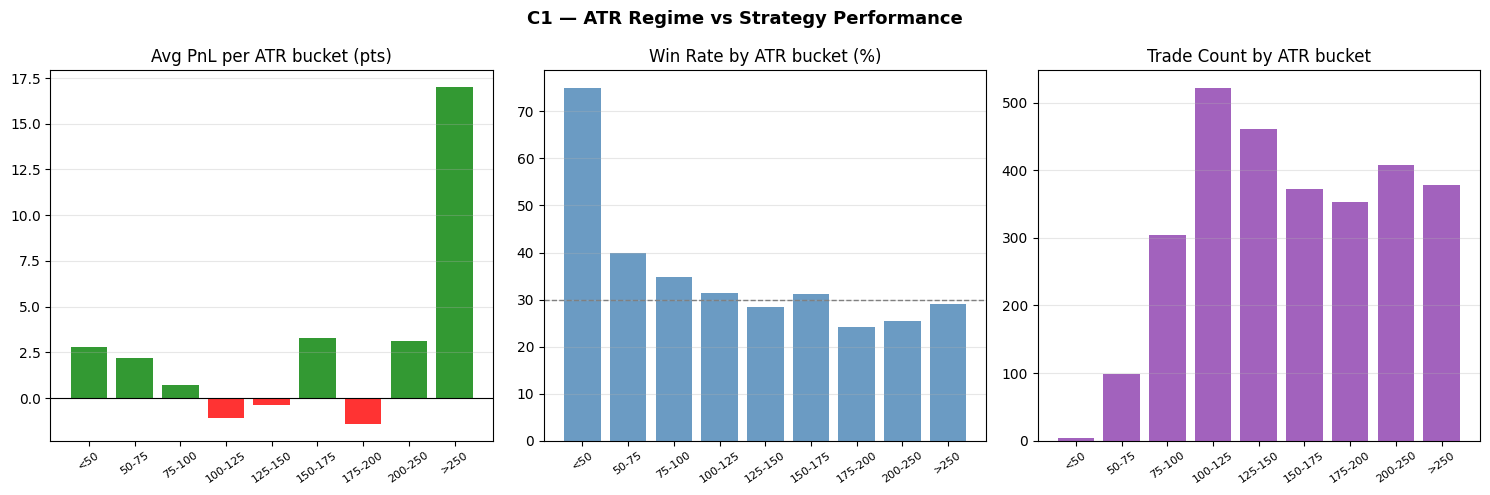

Saved: ctx_atr.png


In [10]:
# Visualise ATR regime
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('C1 — ATR Regime vs Strategy Performance', fontsize=13, fontweight='bold')

x = list(atr_fine.index)
xpos = range(len(x))

ax = axes[0]
colors_bar = ['green' if v > 0 else 'red' for v in atr_fine['avg_pnl']]
ax.bar(xpos, atr_fine['avg_pnl'], color=colors_bar, alpha=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(x, rotation=35, fontsize=8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Avg PnL per ATR bucket (pts)')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
ax.bar(xpos, atr_fine['win_rate'], color='steelblue', alpha=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(x, rotation=35, fontsize=8)
ax.axhline(30, color='gray', ls='--', lw=1)
ax.set_title('Win Rate by ATR bucket (%)')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[2]
ax.bar(xpos, atr_fine['trades'], color='#7B1FA2', alpha=0.7)
ax.set_xticks(xpos); ax.set_xticklabels(x, rotation=35, fontsize=8)
ax.set_title('Trade Count by ATR bucket')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'ctx_atr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ctx_atr.png')

## 6. C2 — Pre-Session Direction (08:00 → 09:15)

In [11]:
# Pre-session move buckets
ctx_trades['presession_bucket'] = pd.cut(
    ctx_trades['presession_move'],
    bins=[-999, -60, -30, -10, 10, 30, 60, 999],
    labels=['<-60', '-60:-30', '-30:-10', '-10:+10', '+10:+30', '+30:+60', '>+60']
)

pre_perf = ctx_trades.groupby('presession_bucket', observed=True).agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl   = ('pnl', 'mean'),
).round(1)

print('=== Pre-Session Move vs Performance ===')
print(pre_perf.to_string())

# Direction alignment: did the trade go WITH or AGAINST the pre-session move?
ctx_trades['pre_dir'] = np.where(ctx_trades['presession_move'] > 5, 'up',
                         np.where(ctx_trades['presession_move'] < -5, 'down', 'flat'))
ctx_trades['trade_with_pre'] = (
    ((ctx_trades['pre_dir'] == 'up')   & (ctx_trades['direction'] == 'long')) |
    ((ctx_trades['pre_dir'] == 'down') & (ctx_trades['direction'] == 'short'))
)
ctx_trades['trade_against_pre'] = (
    ((ctx_trades['pre_dir'] == 'up')   & (ctx_trades['direction'] == 'short')) |
    ((ctx_trades['pre_dir'] == 'down') & (ctx_trades['direction'] == 'long'))
)

print('\n=== Trade Aligned WITH vs AGAINST Pre-Session Direction ===')
for label, mask in [
    ('With pre-session',    ctx_trades['trade_with_pre']),
    ('Against pre-session', ctx_trades['trade_against_pre']),
    ('Flat pre-session',    ctx_trades['pre_dir'] == 'flat'),
]:
    sub = ctx_trades[mask]
    if len(sub) == 0: continue
    pf = sub[sub['pnl']>0]['pnl'].sum() / abs(sub[sub['pnl']<0]['pnl'].sum()) if len(sub[sub['pnl']<0]) else np.inf
    print(f'  {label:<26} : n={len(sub):,}  WR={( sub["pnl"]>0).mean()*100:.1f}%  '
          f'avg={sub["pnl"].mean():.1f}  PF={pf:.2f}  total={sub["pnl"].sum():,.0f}')

=== Pre-Session Move vs Performance ===
                   trades  total_pnl  win_rate  avg_pnl
presession_bucket                                      
<-60                  272     1513.4      28.3      5.6
-60:-30               416     1586.6      29.1      3.8
-30:-10               479     1498.9      31.9      3.1
-10:+10               638     2197.3      32.3      3.4
+10:+30               458     -243.8      28.2     -0.5
+30:+60               403      572.4      26.3      1.4
>+60                  235      926.0      28.1      3.9

=== Trade Aligned WITH vs AGAINST Pre-Session Direction ===
  With pre-session           : n=1,278  WR=28.8%  avg=3.2  PF=1.20  total=4,149
  Against pre-session        : n=1,307  WR=29.2%  avg=1.4  PF=1.09  total=1,872
  Flat pre-session           : n=316  WR=34.5%  avg=6.4  PF=1.47  total=2,031


In [12]:
# Scan: what if we only trade WITH or only AGAINST pre-session direction?
results_pre = {}

for label, mask in [
    ('base (no filter)',       pd.Series(True, index=ctx.index)),
    ('with_pre (>+5 pts)',     ctx['presession_move'] > 5),
    ('against_pre (<-5 pts)',  ctx['presession_move'] < -5),
    ('presession flat',        ctx['presession_move'].abs() <= 5),
    ('presession strong (>30)', ctx['presession_move'].abs() > 30),
    ('presession moderate',    (ctx['presession_move'].abs() > 5) & (ctx['presession_move'].abs() <= 30)),
]:
    # Need to also filter to trades that actually have ctx rows
    filtered_ctx = ctx[mask.reindex(ctx.index, fill_value=False)]
    df_v = run_on_context(filtered_ctx)
    results_pre[label] = metrics(df_v, label)

pre_scan = pd.DataFrame(results_pre.values()).set_index('label')
print('=== Pre-Session Filter Scan ===')
print(pre_scan[['n_trades','win_rate_%','profit_factor','total_pnl','avg_trade','sharpe','max_dd']].to_string())

=== Pre-Session Filter Scan ===
                         n_trades  win_rate_%  profit_factor  total_pnl  avg_trade  sharpe  max_dd
label                                                                                             
base (no filter)             2901        29.6           1.17     8051.0       2.78    0.83 -1863.0
with_pre (>+5 pts)           1253        27.9           1.07     1367.0       1.09    0.36 -1005.0
against_pre (<-5 pts)        1332        30.0           1.21     4653.0       3.49    0.95 -1494.0
presession flat               316        34.5           1.47     2031.0       6.43    2.19  -423.0
presession strong (>30)      1326        27.9           1.19     4598.0       3.47    0.88 -1987.0
presession moderate          1259        30.1           1.08     1422.0       1.13    0.42 -1093.0


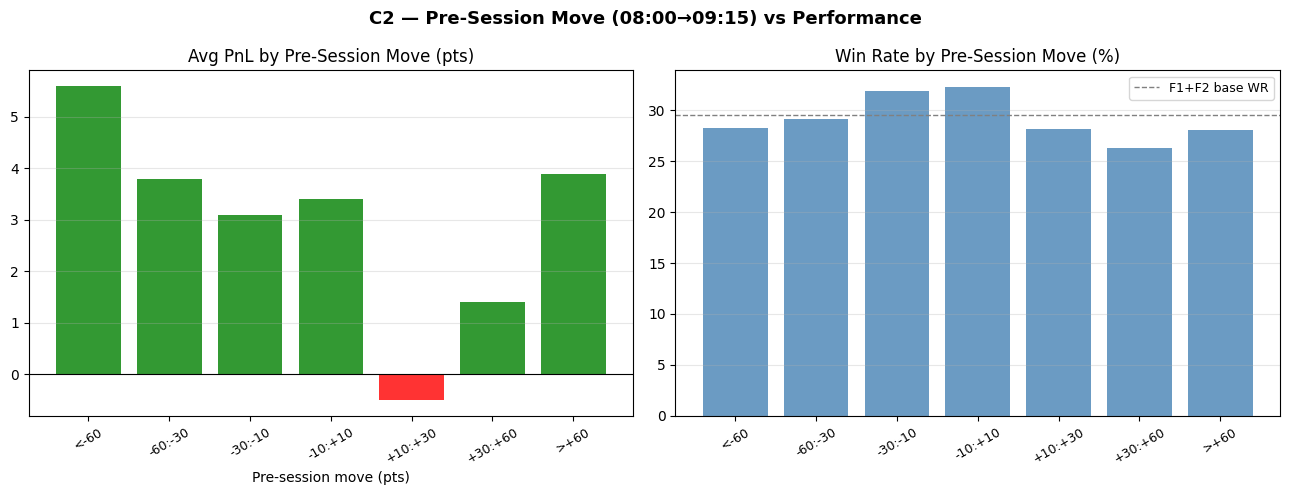

Saved: ctx_presession.png


In [13]:
# Visualise pre-session
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('C2 — Pre-Session Move (08:00→09:15) vs Performance', fontsize=13, fontweight='bold')

labels_pre = list(pre_perf.index)
xpos = range(len(labels_pre))

ax = axes[0]
c = ['green' if v > 0 else 'red' for v in pre_perf['avg_pnl']]
ax.bar(xpos, pre_perf['avg_pnl'], color=c, alpha=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(labels_pre, rotation=30, fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Avg PnL by Pre-Session Move (pts)')
ax.set_xlabel('Pre-session move (pts)')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
ax.bar(xpos, pre_perf['win_rate'], color='steelblue', alpha=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(labels_pre, rotation=30, fontsize=9)
ax.axhline(29.5, color='gray', ls='--', lw=1, label='F1+F2 base WR')
ax.set_title('Win Rate by Pre-Session Move (%)')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'ctx_presession.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ctx_presession.png')

## 7. C3 — Opening Gap Analysis

In [14]:
# Gap buckets
ctx_trades['gap_bucket'] = pd.cut(
    ctx_trades['gap_abs'],
    bins=[0, 10, 25, 50, 75, 100, 9999],
    labels=['0-10', '10-25', '25-50', '50-75', '75-100', '>100']
)

gap_perf = ctx_trades.groupby('gap_bucket', observed=True).agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl   = ('pnl', 'mean'),
).round(1)

print('=== Opening Gap Size vs Performance ===')
print(gap_perf.to_string())

# Gap direction: up-gap vs down-gap
for label, mask in [
    ('Up gap (> +10)',   ctx_trades['gap_pts'] >  10),
    ('Down gap (< -10)', ctx_trades['gap_pts'] < -10),
    ('Flat gap (±10)',   ctx_trades['gap_pts'].abs() <= 10),
    ('Large gap (>50)',  ctx_trades['gap_abs'] >  50),
]:
    sub = ctx_trades[mask]
    if len(sub) == 0: continue
    pf = sub[sub['pnl']>0]['pnl'].sum() / abs(sub[sub['pnl']<0]['pnl'].sum()) if len(sub[sub['pnl']<0]) else np.inf
    print(f'  {label:<22} : n={len(sub):,}  WR={(sub["pnl"]>0).mean()*100:.1f}%  '
          f'avg={sub["pnl"].mean():.1f}  PF={pf:.2f}  total={sub["pnl"].sum():,.0f}')

=== Opening Gap Size vs Performance ===
            trades  total_pnl  win_rate  avg_pnl
gap_bucket                                      
0-10           282      725.8      34.4      2.6
10-25          370      534.8      29.5      1.4
25-50          589      -81.2      30.1     -0.1
50-75          452     -180.2      28.5     -0.4
75-100         324      793.9      28.7      2.5
>100           882     6246.2      28.6      7.1
  Up gap (> +10)         : n=1,293  WR=28.2%  avg=1.2  PF=1.07  total=1,536
  Down gap (< -10)       : n=1,324  WR=29.9%  avg=4.4  PF=1.26  total=5,777
  Flat gap (±10)         : n=284  WR=34.5%  avg=2.6  PF=1.20  total=737
  Large gap (>50)        : n=1,658  WR=28.6%  avg=4.1  PF=1.24  total=6,860


In [15]:
# Gap filter scan
results_gap = {}
for label, mask in [
    ('base',              pd.Series(True, index=ctx.index)),
    ('gap < 50 pts',      ctx['gap_abs'] < 50),
    ('gap < 75 pts',      ctx['gap_abs'] < 75),
    ('gap < 100 pts',     ctx['gap_abs'] < 100),
    ('gap 10–50 pts',    (ctx['gap_abs'] >= 10) & (ctx['gap_abs'] < 50)),
    ('small gap < 25',    ctx['gap_abs'] < 25),
]:
    df_v = run_on_context(ctx[mask.reindex(ctx.index, fill_value=False)])
    results_gap[label] = metrics(df_v, label)

gap_scan = pd.DataFrame(results_gap.values()).set_index('label')
print('=== Gap Filter Scan ===')
print(gap_scan[['n_trades','win_rate_%','profit_factor','total_pnl','avg_trade','sharpe','max_dd']].to_string())

=== Gap Filter Scan ===
                n_trades  win_rate_%  profit_factor  total_pnl  avg_trade  sharpe  max_dd
label                                                                                    
base                2901        29.6           1.17     8051.0       2.78    0.83 -1863.0
gap < 50 pts        1243        30.9           1.07     1191.0       0.96    0.36  -818.0
gap < 75 pts        1695        30.3           1.04     1011.0       0.60    0.22 -1316.0
gap < 100 pts       2019        30.0           1.06     1805.0       0.89    0.32 -1296.0
gap 10–50 pts        960        29.9           1.03      490.0       0.51    0.19 -1093.0
small gap < 25       653        31.5           1.13     1192.0       1.83    0.70  -622.0


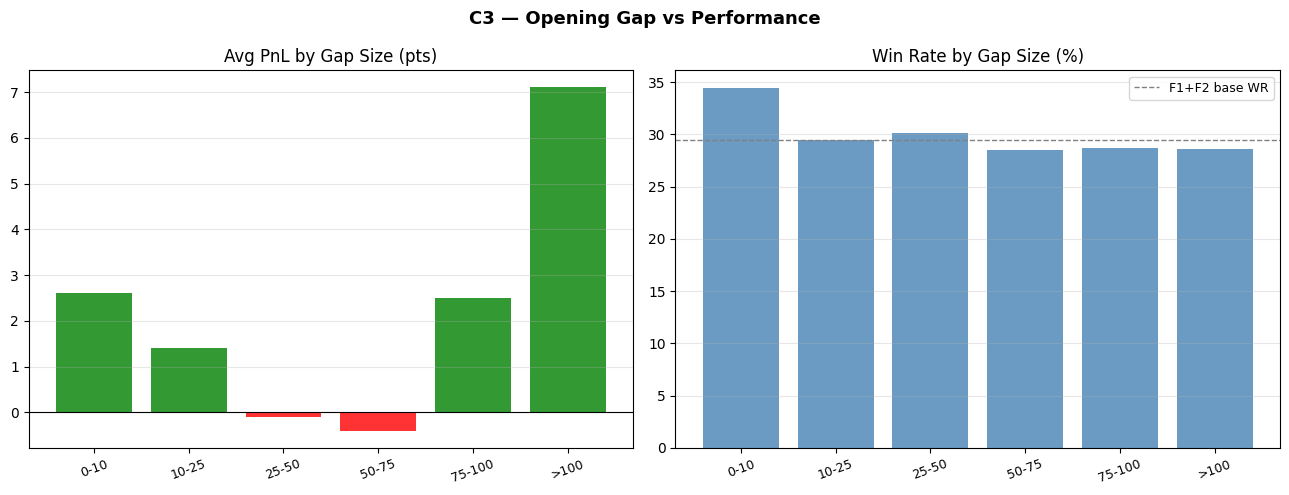

Saved: ctx_gap.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('C3 — Opening Gap vs Performance', fontsize=13, fontweight='bold')

xlabels = list(gap_perf.index)
xpos = range(len(xlabels))

ax = axes[0]
c = ['green' if v > 0 else 'red' for v in gap_perf['avg_pnl']]
ax.bar(xpos, gap_perf['avg_pnl'], color=c, alpha=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(xlabels, rotation=20, fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Avg PnL by Gap Size (pts)')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
ax.bar(xpos, gap_perf['win_rate'], color='steelblue', alpha=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(xlabels, rotation=20, fontsize=9)
ax.axhline(29.5, color='gray', ls='--', lw=1, label='F1+F2 base WR')
ax.set_title('Win Rate by Gap Size (%)')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'ctx_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ctx_gap.png')

## 8. C4 — Monthly Seasonality

In [17]:
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

month_perf = ctx_trades.groupby('month').agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl   = ('pnl', 'mean'),
).round(1)
month_perf.index = [month_map[i] for i in month_perf.index]

print('=== Monthly Performance (F1+F2 base) ===')
print(month_perf.to_string())

# Identify weak months
weak_months  = month_perf[month_perf['avg_pnl'] < 0].index.tolist()
strong_months = month_perf[month_perf['avg_pnl'] > 3].index.tolist()
print(f'\nWeak months (avg PnL < 0)    : {weak_months}')
print(f'Strong months (avg PnL > 3)  : {strong_months}')

=== Monthly Performance (F1+F2 base) ===
     trades  total_pnl  win_rate  avg_pnl
Jan     249     -414.8      27.3     -1.7
Feb     242      725.6      29.3      3.0
Mar     255     2292.5      26.7      9.0
Apr     237     2453.0      35.9     10.4
May     245      349.2      27.8      1.4
Jun     265      637.4      29.1      2.4
Jul     269      -72.9      29.0     -0.3
Aug     249     -739.9      26.9     -3.0
Sep     225       -7.4      28.0     -0.0
Oct     244     1616.5      32.4      6.6
Nov     230      634.8      33.0      2.8
Dec     191      576.8      30.4      3.0

Weak months (avg PnL < 0)    : ['Jan', 'Jul', 'Aug']
Strong months (avg PnL > 3)  : ['Mar', 'Apr', 'Oct']


In [18]:
# Month filter scan
month_name_to_num = {v: k for k, v in month_map.items()}
weak_nums   = [month_name_to_num[m] for m in weak_months]
strong_nums = [month_name_to_num[m] for m in strong_months]

results_month = {}
for label, mask in [
    ('base',                pd.Series(True, index=ctx.index)),
    ('skip weak months',    ~ctx['month'].isin(weak_nums)),
    ('strong months only',  ctx['month'].isin(strong_nums)),
]:
    df_v = run_on_context(ctx[mask.reindex(ctx.index, fill_value=False)])
    results_month[label] = metrics(df_v, label)

month_scan = pd.DataFrame(results_month.values()).set_index('label')
print('=== Month Filter Scan ===')
print(month_scan[['n_trades','win_rate_%','profit_factor','total_pnl','avg_trade','sharpe','max_dd']].to_string())

=== Month Filter Scan ===
                    n_trades  win_rate_%  profit_factor  total_pnl  avg_trade  sharpe  max_dd
label                                                                                        
base                    2901        29.6           1.17     8051.0       2.78    0.83 -1863.0
skip weak months        2134        30.2           1.27     9278.0       4.35    1.23 -1112.0
strong months only       736        31.5           1.54     6362.0       8.64    2.07 -1069.0


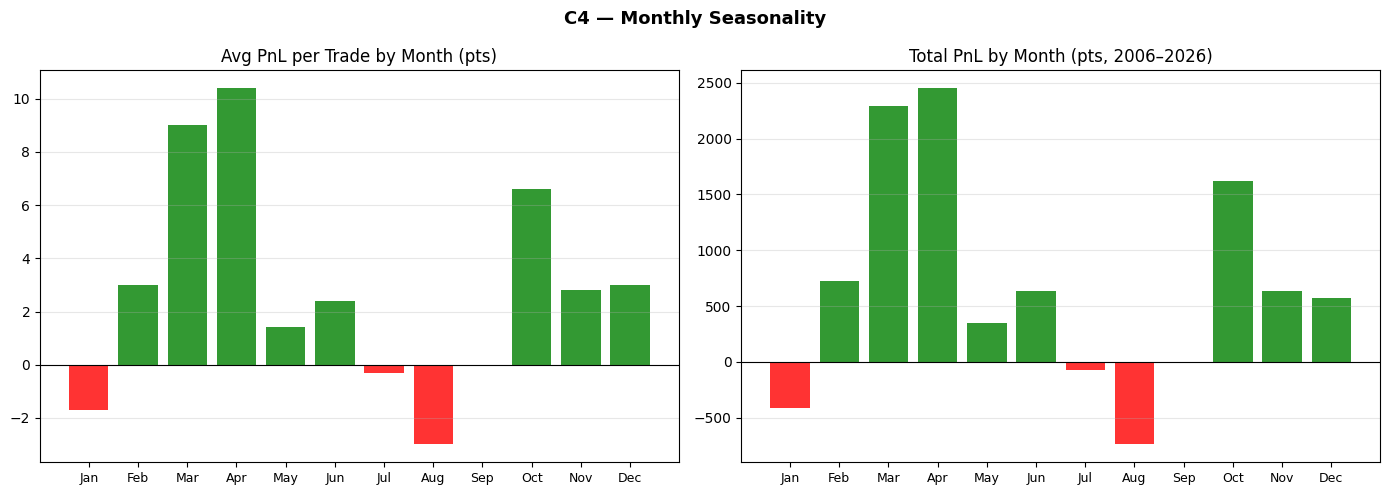

Saved: ctx_monthly.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('C4 — Monthly Seasonality', fontsize=13, fontweight='bold')

months = list(month_perf.index)
xpos   = range(len(months))

ax = axes[0]
c = ['green' if v > 0 else 'red' for v in month_perf['avg_pnl']]
ax.bar(xpos, month_perf['avg_pnl'], color=c, alpha=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(months, fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Avg PnL per Trade by Month (pts)')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
c2 = ['green' if v > 0 else 'red' for v in month_perf['total_pnl']]
ax.bar(xpos, month_perf['total_pnl'], color=c2, alpha=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(months, fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Total PnL by Month (pts, 2006–2026)')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'ctx_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ctx_monthly.png')

## 9. Best Combination — Context Filters on Top of F1+F2

In [20]:
# Pick best filters from each context signal based on scan results above
# Then combine them and compare

# Read best ATR band from scan (by Sharpe)
best_atr = atr_scan['sharpe'].idxmax()
best_atr_lo = int(best_atr.split()[1].split('–')[0])
best_atr_hi = int(best_atr.split()[1].split('–')[1])

# Read best gap filter
best_gap_label = gap_scan.drop('base')['sharpe'].idxmax()

print(f'Best ATR band    : {best_atr}  (Sharpe {atr_scan.loc[best_atr, "sharpe"]})')
print(f'Best gap filter  : {best_gap_label}  (Sharpe {gap_scan.loc[best_gap_label, "sharpe"]})')
print(f'Weak months      : {weak_months}')

# Build combined masks
m_atr   = (ctx['atr14'] >= best_atr_lo) & (ctx['atr14'] <= best_atr_hi)

# Rebuild gap mask from label
if '<' in best_gap_label:
    gap_thresh = int(''.join(filter(str.isdigit, best_gap_label)))
    m_gap = ctx['gap_abs'] < gap_thresh
else:
    # fallback
    m_gap = ctx['gap_abs'] < 75

m_month = ~ctx['month'].isin(weak_nums)

combos = {
    'F1+F2 base'          : pd.Series(True, index=ctx.index),
    '+ C1 ATR'            : m_atr,
    '+ C3 gap'            : m_gap,
    '+ C4 month'          : m_month,
    '+ C1+C3'             : m_atr & m_gap,
    '+ C1+C4'             : m_atr & m_month,
    '+ C3+C4'             : m_gap & m_month,
    '+ C1+C3+C4 (best)'   : m_atr & m_gap & m_month,
}

combo_results = {}
for label, mask in combos.items():
    df_v = run_on_context(ctx[mask.reindex(ctx.index, fill_value=False)])
    combo_results[label] = metrics(df_v, label)

combo_df = pd.DataFrame(combo_results.values()).set_index('label')
print('\n=== Context Filter Combinations ===')
print(combo_df[['n_trades','win_rate_%','profit_factor','total_pnl','avg_trade','sharpe','max_dd']].to_string())

Best ATR band    : ATR 50–175  (Sharpe 0.21)
Best gap filter  : small gap < 25  (Sharpe 0.7)
Weak months      : ['Jan', 'Jul', 'Aug']

=== Context Filter Combinations ===
                   n_trades  win_rate_%  profit_factor  total_pnl  avg_trade  sharpe  max_dd
label                                                                                       
F1+F2 base             2901        29.6           1.17     8051.0       2.78    0.83 -1863.0
+ C1 ATR               1760        31.6           1.04      871.0       0.49    0.21  -932.0
+ C3 gap                653        31.5           1.13     1192.0       1.83    0.70  -622.0
+ C4 month             2134        30.2           1.27     9278.0       4.35    1.23 -1112.0
+ C1+C3                 518        32.2           1.04      270.0       0.52    0.23  -562.0
+ C1+C4                1269        32.3           1.09     1487.0       1.17    0.49  -848.0
+ C3+C4                 478        32.6           1.21     1383.0       2.89    1.08 

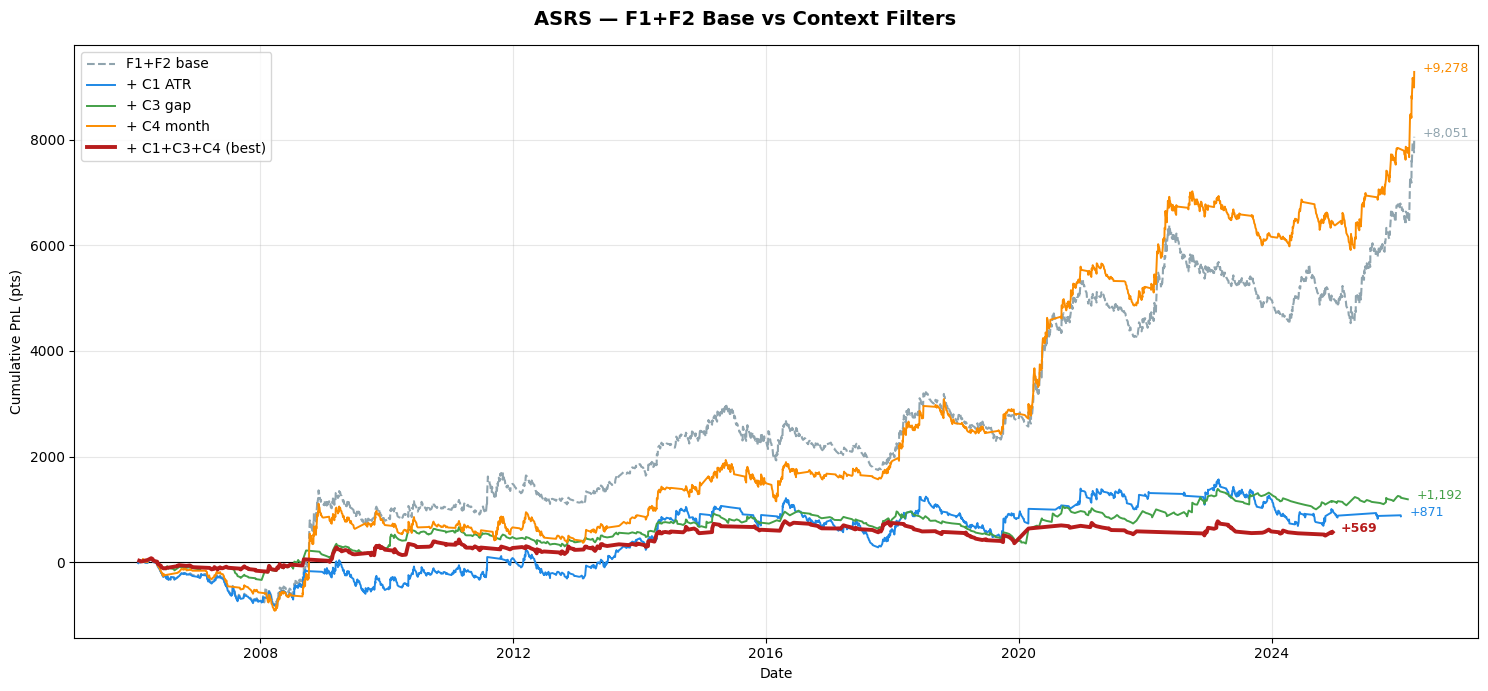

Saved: ctx_equity.png


In [21]:
# Equity curves — base vs each context addition vs best combo
fig, ax = plt.subplots(figsize=(15, 7))
fig.suptitle('ASRS — F1+F2 Base vs Context Filters', fontsize=14, fontweight='bold')

palette = {
    'F1+F2 base'        : ('#90A4AE', '--', 1.5),
    '+ C1 ATR'          : ('#1E88E5', '-',  1.4),
    '+ C3 gap'          : ('#43A047', '-',  1.4),
    '+ C4 month'        : ('#FB8C00', '-',  1.4),
    '+ C1+C3+C4 (best)' : ('#B71C1C', '-',  2.8),
}

for label, (color, ls, lw) in palette.items():
    if label not in combo_results:
        continue
    df_v = run_on_context(
        ctx[combos[label].reindex(ctx.index, fill_value=False)]
    )
    if df_v.empty:
        continue
    cum = df_v['pnl'].cumsum()
    ax.plot(cum.index, cum.values, color=color, lw=lw, ls=ls, label=label,
            zorder=5 if 'best' in label else 3)
    final = cum.iloc[-1]
    ax.annotate(f'{final:+,.0f}',
                xy=(cum.index[-1], final),
                xytext=(6, 0), textcoords='offset points',
                color=color, fontsize=9,
                fontweight='bold' if 'best' in label else 'normal')

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Cumulative PnL (pts)')
ax.set_xlabel('Date')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'ctx_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ctx_equity.png')

In [22]:
# Final scorecard — F1+F2 base vs best combo
best_label = combo_df.drop('F1+F2 base')['sharpe'].idxmax()
m_best     = combo_df.loc[best_label]
m_base_c   = combo_df.loc['F1+F2 base']

print(f'=== Best Context Combo: "{best_label}" ===')
print(f'{"Metric":<20}  {"F1+F2 base":>12}  {"Best combo":>12}  {"Change":>10}')
print('-' * 60)
for col, label in [
    ('n_trades',      'Trades'),
    ('win_rate_%',    'Win rate %'),
    ('profit_factor', 'Profit factor'),
    ('total_pnl',     'Total PnL pts'),
    ('avg_trade',     'Avg trade pts'),
    ('sharpe',        'Sharpe'),
    ('max_dd',        'Max drawdown'),
]:
    b = m_base_c[col]
    a = m_best[col]
    if isinstance(b, float):
        print(f'{label:<20}  {b:>12.2f}  {a:>12.2f}  {a-b:>+10.2f}')
    else:
        print(f'{label:<20}  {b:>12,}  {a:>12,}  {a-b:>+10,}')

=== Best Context Combo: "+ C4 month" ===
Metric                  F1+F2 base    Best combo      Change
------------------------------------------------------------
Trades                     2901.00       2134.00     -767.00
Win rate %                   29.60         30.20       +0.60
Profit factor                 1.17          1.27       +0.10
Total PnL pts              8051.00       9278.00    +1227.00
Avg trade pts                 2.78          4.35       +1.57
Sharpe                        0.83          1.23       +0.40
Max drawdown              -1863.00      -1112.00     +751.00


## 10. Annual Performance — F1+F2 vs Best Context Combo

In [23]:
df_best_combo = run_on_context(
    ctx[combos[best_label].reindex(ctx.index, fill_value=False)]
)

ann_base_c  = df_base.groupby(df_base.index.year)['pnl'].sum().round(1)
ann_best_c  = df_best_combo.groupby(df_best_combo.index.year)['pnl'].sum().round(1)
ann_ctx     = pd.DataFrame({'F1+F2': ann_base_c, best_label: ann_best_c})
ann_ctx['improvement'] = (ann_ctx[best_label] - ann_ctx['F1+F2']).round(1)

print(f'=== Annual PnL: F1+F2 vs {best_label} ===')
print(f'{"Year":<6}  {"F1+F2":>10}  {best_label[:12]:>14}  {"Improvement":>12}')
print('-' * 48)
for yr, row in ann_ctx.iterrows():
    marker = ' ✓' if row['improvement'] > 0 else ' ✗'
    print(f'{yr:<6}  {row["F1+F2"]:>+10.0f}  {row[best_label]:>+14.0f}  {row["improvement"]:>+12.0f}{marker}')

better = (ann_ctx['improvement'] > 0).sum()
print(f'\nBest combo beats F1+F2 in {better}/{len(ann_ctx)} years')

=== Annual PnL: F1+F2 vs + C4 month ===
Year         F1+F2      + C4 month   Improvement
------------------------------------------------
2006          -241            -159           +82 ✓
2007          -488            -410           +78 ✓
2008         +1828           +1415          -413 ✗
2009          -313            -141          +172 ✓
2010          +225             -46          -271 ✗
2011          +474              +3          -472 ✗
2012          -340            -236          +103 ✓
2013          +692            +467          -225 ✗
2014          +644            +578           -66 ✗
2015          -194             +28          +223 ✓
2016           -54            +180          +234 ✓
2017          -141            +237          +378 ✓
2018          +639            +717           +78 ✓
2019           -19            +178          +197 ✓
2020         +2554           +2722          +168 ✓
2021          -645            -319          +326 ✓
2022          +949           +1528          +5

## 11. Export

In [24]:
# Export context trades
ctx_export = ctx_trades.reset_index()
ctx_export.to_csv(ROOT / 'data' / 'asrs_context_trades.csv', index=False)
print(f'Exported context trades → data/asrs_context_trades.csv')

# Export combo summary
combo_df.to_csv(ROOT / 'data' / 'asrs_context_summary.csv')
print(f'Exported combo summary  → data/asrs_context_summary.csv')

print('\n=== FINAL CONTEXT COMBO SUMMARY ===')
print(combo_df[['n_trades','win_rate_%','profit_factor','total_pnl','avg_trade','sharpe','max_dd']].to_string())

Exported context trades → data/asrs_context_trades.csv
Exported combo summary  → data/asrs_context_summary.csv

=== FINAL CONTEXT COMBO SUMMARY ===
                   n_trades  win_rate_%  profit_factor  total_pnl  avg_trade  sharpe  max_dd
label                                                                                       
F1+F2 base             2901        29.6           1.17     8051.0       2.78    0.83 -1863.0
+ C1 ATR               1760        31.6           1.04      871.0       0.49    0.21  -932.0
+ C3 gap                653        31.5           1.13     1192.0       1.83    0.70  -622.0
+ C4 month             2134        30.2           1.27     9278.0       4.35    1.23 -1112.0
+ C1+C3                 518        32.2           1.04      270.0       0.52    0.23  -562.0
+ C1+C4                1269        32.3           1.09     1487.0       1.17    0.49  -848.0
+ C3+C4                 478        32.6           1.21     1383.0       2.89    1.08  -444.0
+ C1+C3+C4 (bes